# 1. Теоретическая часть

При решении научных, технических и инженерных задач обычно используют три основных подхода: **аналитические методы**, **численные методы** и **искусственные нейронные сети**.

## Аналитические методы
Аналитические методы позволяют получить **точное решение** задачи в виде формулы или явного математического выражения.  
Их преимущество заключается в высокой точности и наглядности результата.  
Однако такие методы работают в основном только для **частных и достаточно простых случаев**, когда задачу можно существенно упростить.

## Численные методы
Численные методы являются более **универсальными**, так как позволяют решать сложные задачи, для которых невозможно получить точное аналитическое решение.  
Они широко применяются в моделировании физических, технических и инженерных процессов.  
Их главный недостаток — **высокая вычислительная сложность**: для получения результата может потребоваться большое количество времени и вычислительных ресурсов.

## Искусственные нейронные сети
Искусственные нейронные сети (ИНС) занимают промежуточное положение между этими подходами.  
Они не выводят формулу напрямую и не решают задачу пошагово, как численные методы, а **обучаются на основе реальных данных**: измерений, экспериментов или результатов моделирования.

После обучения нейронная сеть может быстро предсказывать результат для новых входных данных.  
Это особенно полезно в тех случаях, когда:
- аналитическая модель слишком сложна или неизвестна;
- численный расчёт слишком долгий;
- имеется достаточно большой набор экспериментальных данных.

При этом нейронная сеть обычно не повторяет все случайные флуктуации измерений, а выделяет **основную зависимость**, то есть в некотором смысле **сглаживает шум**.  
Поэтому ИНС позволяют получать **быстрые и достаточно точные прогнозы**, близкие к реальным измерениям.

## Кратко об ИНС
Искусственная нейронная сеть состоит из **нейронов**, объединённых в слои:
- **входной слой** принимает исходные признаки;
- **скрытые слои** находят внутренние зависимости между данными;
- **выходной слой** формирует результат.

Каждый нейрон получает входные значения, умножает их на веса, складывает и передаёт дальше через функцию активации.  
Во время обучения веса подбираются так, чтобы ошибка между предсказанием сети и правильным ответом становилась как можно меньше.

## Зачем нужны NumPy и pandas
Перед использованием `scikit-learn` необходимо уметь работать с данными, поэтому ранее изучались библиотеки **NumPy** и **pandas**.

### NumPy
`NumPy` используется для работы с массивами данных.  
В задачах машинного обучения входные данные обычно представляются в виде:
- матрицы признаков `X`, где строки — это объекты, а столбцы — признаки;
- вектора ответов `y`, содержащего правильные значения или классы.

Именно такие структуры данных чаще всего подаются на вход моделям машинного обучения.

### pandas
`pandas` используется для хранения и обработки датасетов в табличном виде.  
С его помощью удобно:
- загружать данные;
- просматривать таблицы;
- выбирать нужные столбцы;
- анализировать структуру датасета;
- подготавливать данные перед обучением модели.

Таким образом:
- `pandas` удобно использовать для работы с датасетом как с таблицей;
- `NumPy` удобно использовать для передачи данных в модели машинного обучения.

# 2. Примеры использования scikit-learn

В этом разделе показаны базовые шаги работы с библиотекой `scikit-learn`:

1. разделение данных на обучающую и тестовую выборки;
2. стандартизация признаков;
3. создание и обучение нейронных сетей.

Данный раздел нужен как справочный материал: отсюда можно брать шаблоны для практической части.

## 2.1. Разделение данных на обучающую и тестовую выборки

Перед обучением модели данные обычно делят на две части:

- **обучающая выборка** — используется для обучения модели;
- **тестовая выборка** — используется для проверки качества модели на новых данных.

Для этого используется функция `train_test_split()`.

### Основные параметры:
- `X` — матрица признаков;
- `y` — вектор ответов;
- `test_size=0.25` — доля объектов, которая пойдёт в тестовую выборку;
- `random_state=42` — фиксирует случайное разбиение, чтобы результат можно было повторить;
- `stratify=y` — сохраняет одинаковую пропорцию классов в обучающей и тестовой выборках.

In [ ]:
# импортируем встроенный датасет для примера классификации
from sklearn.datasets import load_iris

# импортируем функцию разбиения на обучающую и тестовую выборки
from sklearn.model_selection import train_test_split

# загружаем датасет Iris
iris = load_iris(as_frame=True)

# создаём матрицу признаков X:
# берём все столбцы, кроме столбца target
X = iris.frame.drop(columns="target").to_numpy()

# создаём вектор ответов y:
# берём только столбец target
y = iris.frame["target"].to_numpy()

# разделяем данные на обучающую и тестовую выборки
# test_size=0.25 означает, что 25% данных уйдут в тестовую выборку
# random_state=42 фиксирует случайное разбиение
# stratify=y сохраняет одинаковую пропорцию классов
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# выводим размеры полученных выборок
print("Размер обучающей выборки X_train:", X_train.shape)
print("Размер тестовой выборки X_test:  ", X_test.shape)
print("Размер обучающих ответов y_train:", y_train.shape)
print("Размер тестовых ответов y_test:  ", y_test.shape)

Размер обучающей выборки X_train: (112, 4)
Размер тестовой выборки X_test:   (38, 4)
Размер обучающих ответов y_train: (112,)
Размер тестовых ответов y_test:   (38,)


## 2.2. Стандартизация признаков

Нейронные сети обычно работают лучше, если признаки приведены к одному масштабу.

Для этого используется класс `StandardScaler`.

Он выполняет преобразование:
- среднее значение каждого признака становится примерно 0;
- стандартное отклонение становится примерно 1.

### Основные методы:
- `fit(X)` — вычисляет параметры стандартизации по данным;
- `transform(X)` — применяет стандартизацию;
- `fit_transform(X)` — сначала вычисляет параметры, затем сразу преобразует данные.

### Важно:
`fit()` нужно вызывать только на **обучающей выборке**,  
а к тестовой применять только `transform()`.

In [ ]:
# импортируем класс для стандартизации признаков
from sklearn.preprocessing import StandardScaler

# создаём объект стандартизатора
scaler = StandardScaler()

# обучаем стандартизатор на обучающей выборке и сразу преобразуем её
X_train_scaled = scaler.fit_transform(X_train)

# применяем то же самое преобразование к тестовой выборке
X_test_scaled = scaler.transform(X_test)

# выводим первые строки до и после стандартизации
print("Первые 3 объекта до стандартизации:\n")
print(X_train[:3])

print("\nПервые 3 объекта после стандартизации:\n")
print(X_train_scaled[:3])

Первые 3 объекта до стандартизации:

[[7.4 2.8 6.1 1.9]
 [7.7 2.8 6.7 2. ]
 [5.5 2.4 3.7 1. ]]

Первые 3 объекта после стандартизации:

[[ 1.79213839 -0.60238047  1.31532306  0.92095427]
 [ 2.14531053 -0.60238047  1.65320421  1.05135487]
 [-0.4446185  -1.50797259 -0.03620155 -0.25265117]]


## 2.3. Пример создания и обучения `MLPClassifier`

`MLPClassifier` — это многослойный перцептрон для **классификации**.

### Основные параметры:
- `hidden_layer_sizes=(10, 10)` — структура скрытых слоёв:
  - первый скрытый слой содержит 10 нейронов,
  - второй скрытый слой содержит 10 нейронов;
- `activation='relu'` — функция активации:
  - `'relu'` — самая популярная функция,
  - `'tanh'` — значения от -1 до 1,
  - `'logistic'` — сигмоида;
- `solver='adam'` — алгоритм оптимизации весов:
  - `'adam'` — удобный универсальный вариант;
- `max_iter=2000` — максимальное число итераций обучения;
- `random_state=42` — фиксирует случайность и позволяет воспроизводить результат.

### Основные методы:
- `fit(X, y)` — обучение модели;
- `predict(X)` — предсказание классов;
- `predict_proba(X)` — предсказание вероятностей классов;
- `score(X, y)` — вычисление качества модели.

In [ ]:
# импортируем нейронную сеть для классификации
from sklearn.neural_network import MLPClassifier

# импортируем метрику точности
from sklearn.metrics import accuracy_score

# создаём модель многослойного перцептрона для классификации
# hidden_layer_sizes=(10, 10) — два скрытых слоя по 10 нейронов
# activation='relu' — функция активации ReLU
# solver='adam' — алгоритм оптимизации
# max_iter=2000 — максимум 2000 итераций обучения
# random_state=42 — фиксация случайности
mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation="relu",
    solver="adam",
    max_iter=2000,
    random_state=42
)

# обучаем модель на стандартизованных обучающих данных
mlp_classifier.fit(X_train_scaled, y_train)

# получаем предсказания классов для тестовой выборки
y_pred_class = mlp_classifier.predict(X_test_scaled)

# вычисляем точность классификации
accuracy = accuracy_score(y_test, y_pred_class)

# выводим результат
print("Точность классификации:", accuracy)

# получаем вероятности принадлежности объектов к классам
# каждая строка — один объект
# каждый столбец — вероятность соответствующего класса
y_pred_proba = mlp_classifier.predict_proba(X_test_scaled)

# выводим вероятности для первых 5 объектов
print("Вероятности классов для первых 5 объектов:\n")
print(y_pred_proba[:5])

# выводим количество итераций, которое реально потребовалось модели
print("Количество выполненных итераций:", mlp_classifier.n_iter_)

# выводим значение функции потерь на последней итерации
print("Финальное значение функции потерь:", mlp_classifier.loss_)

Точность классификации: 0.9473684210526315
Вероятности классов для первых 5 объектов:

[[9.98943438e-01 8.03217993e-04 2.53343983e-04]
 [8.77866708e-03 8.88875361e-01 1.02345972e-01]
 [3.21042308e-03 9.84365041e-01 1.24245357e-02]
 [1.57955405e-03 9.93758794e-01 4.66165229e-03]
 [9.97471168e-01 2.25517615e-03 2.73655558e-04]]
Количество выполненных итераций: 593
Финальное значение функции потерь: 0.05850165440738247


## 2.4. Пример создания и обучения `MLPRegressor`

`MLPRegressor` — это многослойный перцептрон для **регрессии**,  
то есть для предсказания **числового значения**.

В качестве примера возьмём встроенный датасет `diabetes`.

### Основные параметры:
- `hidden_layer_sizes=(50, 30)` — два скрытых слоя:
  - первый слой — 50 нейронов,
  - второй слой — 30 нейронов;
- `activation='relu'` — функция активации;
- `solver='adam'` — алгоритм оптимизации;
- `max_iter=3000` — максимальное число итераций;
- `random_state=42` — фиксация случайности.

### Основные методы:
- `fit(X, y)` — обучение;
- `predict(X)` — предсказание числовых значений;
- `score(X, y)` — для регрессии обычно возвращает коэффициент детерминации `R^2`.

In [ ]:
# импортируем встроенный датасет для регрессии
from sklearn.datasets import load_diabetes

# импортируем нейронную сеть для регрессии
from sklearn.neural_network import MLPRegressor

# импортируем метрики качества регрессии
from sklearn.metrics import mean_squared_error, r2_score

# загружаем датасет diabetes
diabetes = load_diabetes(as_frame=True)

# создаём матрицу признаков X_reg:
# берём все столбцы, кроме target
X_reg = diabetes.frame.drop(columns="target").to_numpy()

# создаём вектор ответов y_reg:
# берём столбец target
y_reg = diabetes.frame["target"].to_numpy()

# разделяем данные на обучающую и тестовую выборки
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg,
    y_reg,
    test_size=0.25,
    random_state=42
)

# создаём стандартизатор
scaler_reg = StandardScaler()

# стандартизуем обучающие данные
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)

# стандартизуем тестовые данные
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

# создаём модель многослойного перцептрона для регрессии
# hidden_layer_sizes=(50, 30) — два скрытых слоя
# activation='relu' — функция активации
# solver='adam' — алгоритм оптимизации
# max_iter=3000 — максимум 3000 итераций
# random_state=42 — фиксация случайности
mlp_regressor = MLPRegressor(
    hidden_layer_sizes=(50, 30),
    activation="relu",
    solver="adam",
    max_iter=3000,
    random_state=42
)

# обучаем модель
mlp_regressor.fit(X_train_reg_scaled, y_train_reg)

# получаем предсказания модели
y_pred_reg = mlp_regressor.predict(X_test_reg_scaled)

# вычисляем среднюю квадратичную ошибку
mse = mean_squared_error(y_test_reg, y_pred_reg)

# вычисляем коэффициент детерминации R^2
r2 = r2_score(y_test_reg, y_pred_reg)

# выводим метрики качества
print("Средняя квадратичная ошибка MSE:", mse)
print("Коэффициент детерминации R^2:   ", r2)

# выводим количество итераций, которое реально выполнила модель
print("Количество выполненных итераций:", mlp_regressor.n_iter_)

# выводим финальное значение функции потерь
print("Финальное значение функции потерь:", mlp_regressor.loss_)

Средняя квадратичная ошибка MSE: 4372.039077407049
Коэффициент детерминации R^2:    0.20935183759084341
Количество выполненных итераций: 3000
Финальное значение функции потерь: 296.7498965485282


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(


## 2.5. Дополнительный пример: `Perceptron`

`Perceptron` — это простейшая нейросетевая модель для **линейной классификации**.

В отличие от `MLPClassifier`, у перцептрона нет нескольких скрытых слоёв.  
Он строит только **линейную границу** между классами.

### Основные параметры:
- `max_iter=1000` — максимальное число итераций обучения;
- `eta0=0.1` — скорость обучения;
- `random_state=42` — фиксация случайности;
- `tol=1e-3` — порог остановки обучения.

Этот пример можно использовать как самый простой шаблон нейросети.

In [ ]:
# импортируем простейшую нейронную модель — перцептрон
from sklearn.linear_model import Perceptron

# создаём модель перцептрона
# max_iter=1000 — максимум 1000 итераций
# eta0=0.1 — скорость обучения
# random_state=42 — фиксация случайности
# tol=1e-3 — порог остановки обучения
perceptron_model = Perceptron(
    max_iter=1000,
    eta0=0.1,
    random_state=42,
    tol=1e-3
)

# обучаем перцептрон на стандартизованных данных классификации
perceptron_model.fit(X_train_scaled, y_train)

# получаем предсказания
y_pred_perc = perceptron_model.predict(X_test_scaled)

# вычисляем точность
accuracy_perc = accuracy_score(y_test, y_pred_perc)

# выводим точность
print("Точность перцептрона:", accuracy_perc)

Точность перцептрона: 0.8947368421052632


## 2.6. Краткий шаблон использования любой модели scikit-learn

Почти все модели в `scikit-learn` используются по одной и той же схеме:

1. подготовить данные;
2. разделить данные на обучающую и тестовую выборки;
3. при необходимости стандартизовать признаки;
4. создать объект модели;
5. обучить модель методом `fit()`;
6. получить предсказания методом `predict()`;
7. оценить качество модели с помощью метрик.

# 3. Практические задания

Ниже приведены 3 задания по основным назначениям искусственных нейронных сетей:

1. **Классификация** — определить класс объекта по набору признаков.
2. **Регрессия** — предсказать числовое значение по нескольким признакам.
3. **Аппроксимация** — восстановить основную зависимость по экспериментальным данным с шумом.

Во всех заданиях необходимо:
- подготовить данные;
- выделить признаки `X` и ответы `y`;
- разделить данные на обучающую и тестовую выборки;
- выполнить стандартизацию признаков;
- создать и обучить модель;
- получить предсказания;
- оценить качество модели;
- построить необходимые графики.

## 3.1. Задание 1 — Классификация

Для этого задания используется встроенный датасет **Wine** из `scikit-learn`.

### Что содержит датасет
Датасет состоит из результатов химического анализа вин.  
Каждая строка — это один образец вина.  
Каждый столбец — числовой признак, характеризующий состав вина.

### Основные признаки
В датасете содержатся, например, такие признаки:
- `alcohol` — содержание алкоголя;
- `malic_acid` — содержание яблочной кислоты;
- `ash` — зольность;
- `magnesium` — содержание магния;
- `total_phenols` — суммарное содержание фенолов;
- `flavanoids` — содержание флаваноидов;
- `color_intensity` — интенсивность цвета;
- `hue` — оттенок;
- `proline` — содержание пролина.

Всего используется **13 признаков**.

### Что является выходом
Выходной столбец `target` — это **класс вина**.  
Нужно по химическим признакам определить, к какому классу относится образец.

### Что нужно сделать
Обучить `MLPClassifier` и оценить качество классификации.

Первые 5 строк датасета:    alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  prol

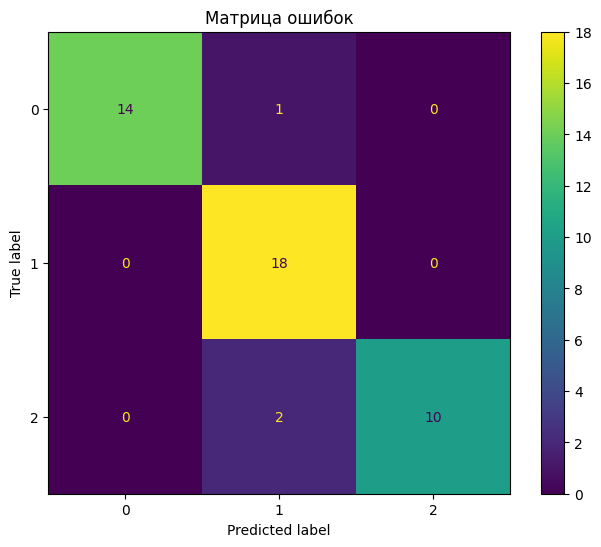

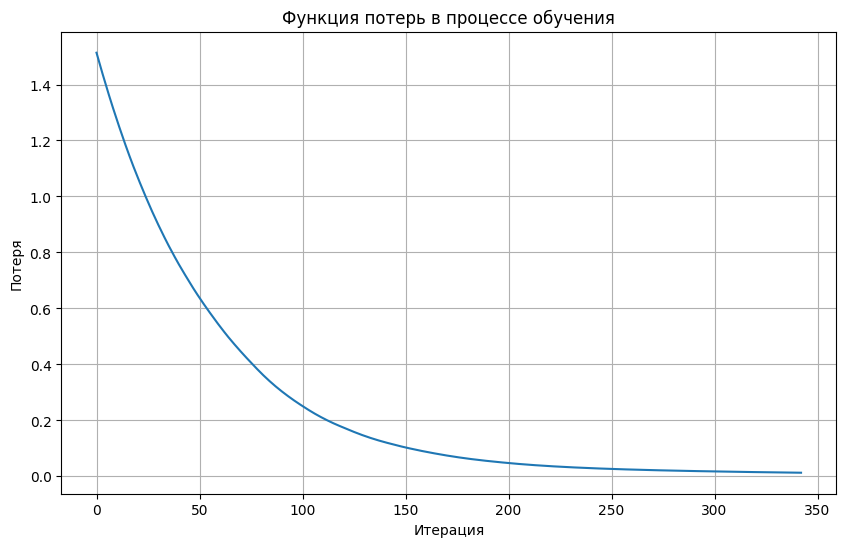

In [ ]:
# Импортировать необходимые библиотеки для работы с датасетом, разбиения данных,
# стандартизации, нейронной сети для классификации и метрик качества
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Загрузить датасет Wine в формате pandas DataFrame
wine = load_wine(as_frame=True)

# Создать DataFrame со всеми признаками и целевым столбцом target
df_wine = wine.frame

# Вывести первые 5 строк таблицы
preview_wine = df_wine.head()

#Вывести общую информацию о датасете
describe_wine = df_wine.describe()

print("Первые 5 строк датасета:", preview_wine)
print("\n Описательная статистика:", describe_wine)

#  Выделить матрицу признаков X: взять все столбцы, кроме target
X_wine = wine.frame.drop(columns="target").to_numpy()

# Выделить вектор ответов y: взять столбец target
y_wine = wine.frame["target"].to_numpy()

# Вывести размерности X и y
print("Размер X:", X_wine.shape)
print("Размер y:", y_wine.shape)

# Разделить данные на обучающую и тестовую выборки
# Использовать test_size=0.25, random_state=42, stratify=y_wine
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine,
    y_wine,
    test_size=0.25,
    random_state=42,
    stratify=y_wine
)

# Создать объект StandardScaler
scaler_wine = StandardScaler()

# Обучить стандартизатор на обучающей выборке и преобразовать её
X_train_wine_scaled = scaler_wine.fit_transform(X_train_wine)

# Преобразовать тестовую выборку с помощью уже обученного стандартизатора
X_test_wine_scaled = scaler_wine.transform(X_test_wine)


# Создать модель MLPClassifier
# hidden_layer_sizes=(20, 10) — два скрытых слоя: 20 и 10 нейронов
# activation='relu' — функция активации ReLU
# solver='adam' — алгоритм оптимизации
# max_iter=3000 — максимальное число итераций обучения
# random_state=42 — фиксация случайности
wine_model = MLPClassifier(
    hidden_layer_sizes=(20, 10),
    activation="relu",
    solver="adam",
    max_iter=3000,
    random_state=42
)

# Обучить модель классификации на стандартизованных обучающих данных
wine_model.fit(X_train_wine_scaled, y_train_wine)

# Получить предсказания модели на тестовой выборке
y_pred_wine = wine_model.predict(X_test_wine_scaled)

# Вычислить точность классификации
wine_accuracy = accuracy_score(y_test_wine, y_pred_wine)

# Вывести точность модели
print("Точность классификации:", wine_accuracy)

# Вывести подробный отчёт classification_report
wine_report = classification_report(y_test_wine, y_pred_wine)
print("\n Отчёт классификации:", wine_report)

# Построить матрицу ошибок с помощью ConfusionMatrixDisplay.from_predictions(...)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_wine,
    y_pred_wine,
    ax=ax,
)
plt.title("Матрица ошибок")
plt.show()

# Построить график функции потерь в процессе обучения
# Использовать wine_model.loss_curve_
plt.figure(figsize=(10, 6))
plt.plot(wine_model.loss_curve_)
plt.title("Функция потерь в процессе обучения")
plt.xlabel("Итерация")
plt.ylabel("Потеря")
plt.grid(True)
plt.show()


## 3.2. Задание 2 — Регрессия

Для этого задания используется встроенный датасет **Linnerud** из `scikit-learn`.

### Что содержит датасет
Датасет состоит из результатов физических упражнений и физиологических измерений.  
Каждая строка — это один человек.

### Признаки
В качестве входных признаков используются:
- `Chins` — число подтягиваний;
- `Situps` — число подъёмов туловища;
- `Jumps` — число прыжков.

### Выходные данные
В датасете также есть несколько целевых величин:
- `Weight` — вес;
- `Waist` — обхват талии;
- `Pulse` — пульс.

В этом задании нужно предсказать **только `Weight`**, то есть вес человека по результатам упражнений.

### Что нужно сделать
Обучить `MLPRegressor`, получить предсказания и оценить качество регрессии по метрикам `MSE` и `R²`.

Первые 5 строк датасета Linnerud:    Chins  Situps  Jumps  Weight  Waist  Pulse
0    5.0   162.0   60.0   191.0   36.0   50.0
1    2.0   110.0   60.0   189.0   37.0   52.0
2   12.0   101.0  101.0   193.0   38.0   58.0
3   12.0   105.0   37.0   162.0   35.0   62.0
4   13.0   155.0   58.0   189.0   35.0   46.0

Описательная статистика:            Chins      Situps      Jumps      Weight      Waist      Pulse
count  20.000000   20.000000   20.00000   20.000000  20.000000  20.000000
mean    9.450000  145.550000   70.30000  178.600000  35.400000  56.100000
std     5.286278   62.566575   51.27747   24.690505   3.201973   7.210373
min     1.000000   50.000000   25.00000  138.000000  31.000000  46.000000
25%     4.750000  101.000000   39.50000  160.750000  33.000000  51.500000
50%    11.500000  122.500000   54.00000  176.000000  35.000000  55.000000
75%    13.250000  210.000000   85.25000  191.500000  37.000000  60.500000
max    17.000000  251.000000  250.00000  247.000000  46.000000  74.00000

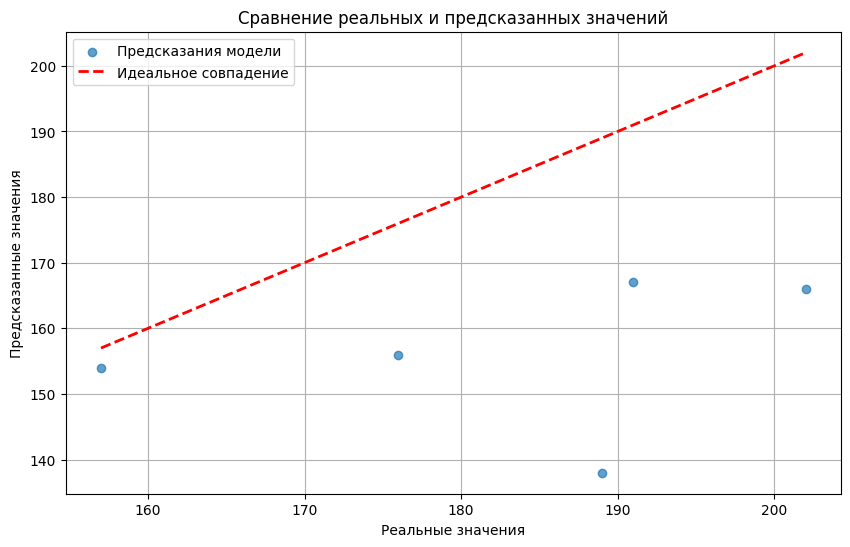

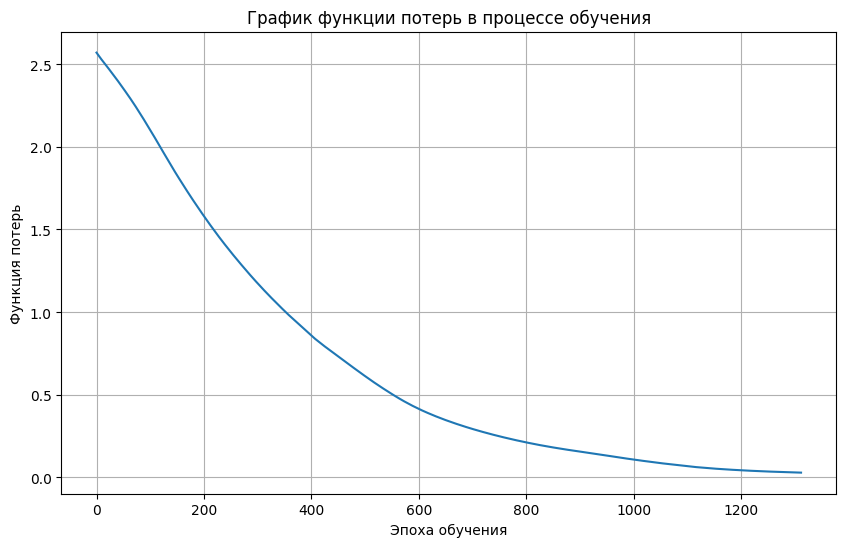

In [ ]:
# Импортировать необходимые библиотеки для работы с датасетом, разбиения данных,
# стандартизации, нейронной сети для регрессии и метрик качества
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_linnerud
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Загрузить датасет Linnerud
linnerud = load_linnerud(as_frame=True)

# Создать DataFrame признаков из linnerud.data
df_linnerud_data = linnerud.data.copy()

# Создать DataFrame целевых значений из linnerud.target
df_linnerud_target = linnerud.target.copy()

# Объединить признаки и целевые значения в одну таблицу
df_linnerud = pd.concat([df_linnerud_data, df_linnerud_target], axis=1)

# Вывести первые 5 строк таблицы
preview_linnerud = df_linnerud.head()
print("Первые 5 строк датасета Linnerud:", preview_linnerud)

# Вывести описательную статистику по числовым столбцам
describe_linnerud = describe_linnerud = df_linnerud.describe()
print("\nОписательная статистика:", describe_linnerud)

# Вывести общую информацию о датасете
print("\nОбщая информация о датасете:")
df_linnerud.info()

# Выделить матрицу признаков X: использовать столбцы Chins, Situps, Jumps
X_linnerud = linnerud.data[["Chins", "Situps", "Jumps"]].to_numpy()

# Выделить вектор ответов y: использовать только столбец Weight
y_linnerud = linnerud.frame["Weight"].to_numpy()

# Вывести размерности X и y
print("Размер X:", X_linnerud.shape)
print("Размер y:", y_linnerud.shape)

# Разделить данные на обучающую и тестовую выборки
# Использовать test_size=0.25, random_state=42
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_linnerud,
    y_linnerud,
    test_size=0.25,
    random_state=42,
)

# Создать объект StandardScaler
scaler_lin = StandardScaler()

# Обучить стандартизатор на обучающей выборке и преобразовать её
X_train_lin_scaled = scaler_lin.fit_transform(X_train_lin)

# Преобразовать тестовую выборку
X_test_lin_scaled = scaler_lin.transform(X_test_lin)

# Создать модель MLPRegressor
# hidden_layer_sizes=(15, 10) — два скрытых слоя: 15 и 10 нейронов
# activation='relu' — функция активации ReLU
# solver='adam' — алгоритм оптимизации
# max_iter=4000 — максимальное число итераций обучения
# random_state=42 — фиксация случайности
linnerud_model = MLPClassifier(
    hidden_layer_sizes=(15, 10),
    activation="relu",
    solver="adam",
    max_iter=4000,
    random_state=42
)

# Обучить модель регрессии на стандартизованных обучающих данных
linnerud_model.fit(X_train_lin_scaled, y_train_lin)

# Получить предсказания модели на тестовой выборке
y_pred_lin = linnerud_model.predict(X_test_lin_scaled)

# Вычислить среднюю квадратичную ошибку MSE
linnerud_mse = mean_squared_error(y_test_lin, y_pred_lin)

# Вычислить коэффициент детерминации R2
linnerud_r2 = r2_score(y_test_lin, y_pred_lin)

# Вывести метрики качества
print("MSE:", linnerud_mse)
print("R2:", linnerud_r2)

# Вывести график сравнения реальных и предсказанных значений
# По оси x — реальные значения y_test_lin
# По оси y — предсказанные значения y_pred_lin
# Также вывести линию идеального совпадения
plt.figure(figsize=(10, 6))
plt.scatter(y_test_lin, y_pred_lin, alpha=0.7, label="Предсказания модели")
plt.plot([y_test_lin.min(), y_test_lin.max()], [y_test_lin.min(), y_test_lin.max()], 'r--', lw=2, label="Идеальное совпадение")
plt.xlabel("Реальные значения")
plt.ylabel("Предсказанные значения")
plt.title("Сравнение реальных и предсказанных значений")
plt.legend()
plt.grid(True)
plt.show()

# Построить график функции потерь в процессе обучения
# Использовать linnerud_model.loss_curve_
plt.figure(figsize=(10, 6))
plt.plot(linnerud_model.loss_curve_)
plt.xlabel("Эпоха обучения")
plt.ylabel("Функция потерь")
plt.title("График функции потерь в процессе обучения")
plt.grid(True)
plt.show()

## 3.3. Задание 3 — Аппроксимация экспериментальной зависимости

В этом задании используется **искусственно сгенерированный датасет**, имитирующий реальные экспериментальные измерения.

### Что содержит датасет
Будет создан один входной параметр:
- `x` — управляющий параметр или координата измерения.

Также будут созданы два выхода:
- `y_true` — истинная теоретическая зависимость;
- `y_noisy` — экспериментальные данные с шумом.

### Какая зависимость используется
В качестве примера можно взять:

\[
y = \sin(x) + 0.3x
\]

После этого к ней нужно добавить случайный шум.  
Такой набор данных хорошо показывает, что нейронная сеть должна не повторить шум, а восстановить **основную закономерность**.

### Что нужно сделать
Обучить `MLPRegressor` и построить итоговый график:
- шумные измерения;
- истинная зависимость;
- предсказание нейронной сети.

          x  y_measured
0 -6.000000   -1.272227
1 -5.939698   -1.514269
2 -5.879397   -1.047070
3 -5.819095   -0.536605
4 -5.758794   -1.344029


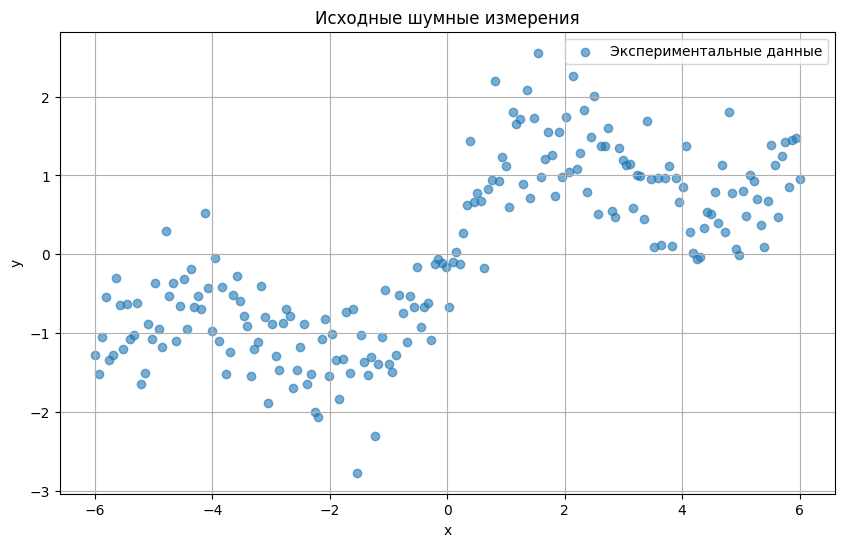

Размер X: (200, 1)
Размер y: (200,)
MSE: 0.25575313740579186
R2: 0.8338181601067112


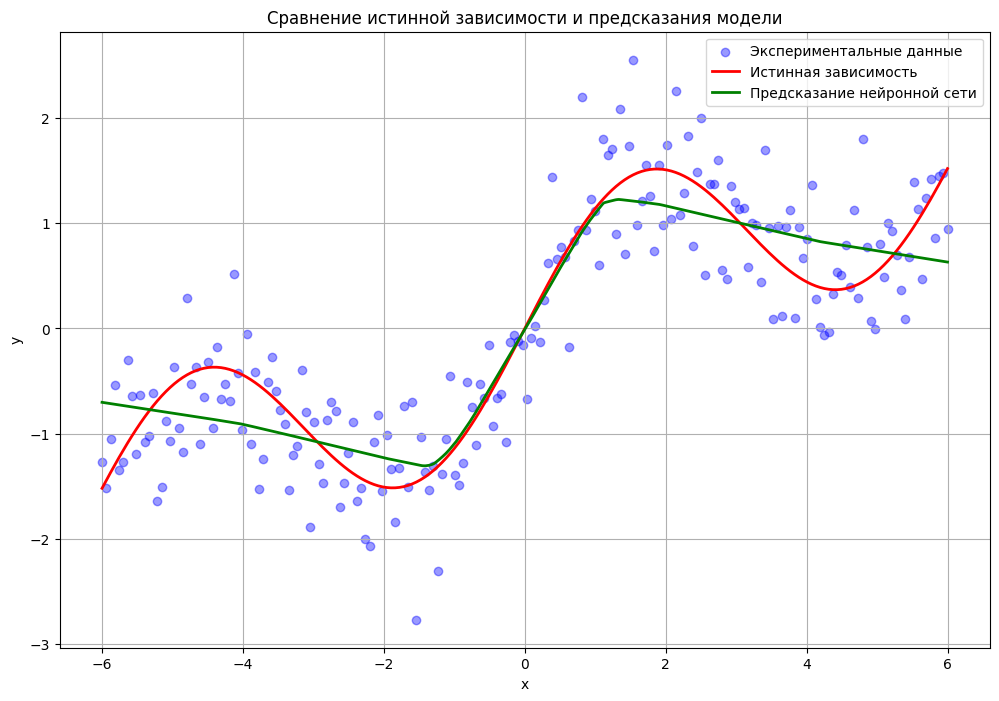

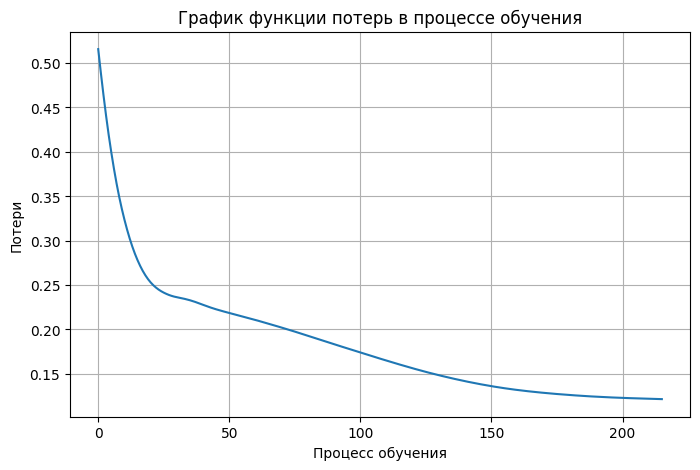

In [ ]:
# Импортировать необходимые библиотеки для генерации данных, разбиения выборки,
# стандартизации, нейронной сети для регрессии и метрик качества
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Зафиксировать генератор случайных чисел для воспроизводимости результата
random_state_value = 42
np.random.seed(random_state_value)

# Создать массив x на выбранном интервале, например от -6 до 6
x_points = np.linspace(-6, 6, 200)

# Вычислить истинную зависимость y_true по формуле y = sin(x) + 0.3*x
y_true = np.sin(x_points) + 0.3 * x_points

# Сгенерировать случайный шум и добавить его к истинной зависимости
# Получить массив шумных измерений y_noisy
noise = np.random.normal(0, 0.5, x_points.shape)
y_noisy = y_true + noise

# Создать DataFrame с экспериментальными данными
# В таблице должен быть столбец x и столбец y_measured
df_signal = pd.DataFrame({'x': x_points, 'y_measured': y_noisy})

# Вывести первые 5 строк таблицы
preview_signal = df_signal.head()
print(preview_signal)

# Построить график исходных экспериментальных точек
# По оси x — x_points
# По оси y — y_noisy
# Ниже студент должен сам написать команды matplotlib
plt.figure(figsize=(10, 6))
plt.scatter(x_points, y_noisy, alpha=0.6, label="Экспериментальные данные")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Исходные шумные измерения")
plt.legend()
plt.grid(True)
plt.show()

# Подготовить матрицу признаков X
# Признак x должен быть двумерным массивом
X_signal = x_points.reshape(-1, 1)

# Подготовить вектор ответов y
y_signal = y_noisy

# Вывести размерности X и y
print("Размер X:", X_signal.shape)
print("Размер y:", y_signal.shape)

# Разделить данные на обучающую и тестовую выборки
# Использовать test_size=0.25, random_state=42
X_train_sig, X_test_sig, y_train_sig, y_test_sig = train_test_split(X_signal, y_signal, test_size=0.25, random_state=random_state_value)

# Создать объект StandardScaler
scaler_signal = StandardScaler()

# Обучить стандартизатор на обучающих данных и преобразовать их
X_train_sig_scaled = scaler_signal.fit_transform(X_train_sig)

# Преобразовать тестовые данные
X_test_sig_scaled = scaler_signal.transform(X_test_sig)

# Создать модель MLPRegressor
# hidden_layer_sizes=(80, 40) — два скрытых слоя: 80 и 40 нейронов
# activation='relu' — функция активации ReLU
# solver='adam' — алгоритм оптимизации
# max_iter=5000 — максимальное число итераций обучения
# random_state=42 — фиксация случайности
signal_model = MLPRegressor(
    hidden_layer_sizes=(80, 40),
    activation='relu',
    solver='adam',
    max_iter=5000,
    random_state=random_state_value
)

# Обучить модель на стандартизованных обучающих данных
signal_model.fit(X_train_sig_scaled, y_train_sig)

# Получить предсказания модели на тестовой выборке
y_pred_signal = signal_model.predict(X_test_sig_scaled)

# Вычислить среднюю квадратичную ошибку MSE
signal_mse = mean_squared_error(y_test_sig, y_pred_signal)

# Вычислить коэффициент детерминации R2
signal_r2 = r2_score(y_test_sig, y_pred_signal)

# Вывести метрики качества
print("MSE:", signal_mse)
print("R2:", signal_r2)

# Создать плотный массив точек x_plot для построения гладкой кривой модели
x_plot = np.linspace(-6, 6, 500).reshape(-1, 1)

# Преобразовать x_plot с помощью обученного стандартизатора
x_plot_scaled = scaler_signal.transform(x_plot)

# Получить предсказания модели на x_plot
y_plot = signal_model.predict(x_plot_scaled)

# Вывести итоговый график:
# 1. исходные шумные измерения
# 2. истинная зависимость y_true
# 3. предсказание нейронной сети y_plot
plt.figure(figsize=(12, 8))
plt.scatter(x_points, y_noisy, alpha=0.4, label="Экспериментальные данные", color="blue")
plt.plot(x_points, y_true, label="Истинная зависимость", color="red", linewidth=2)
plt.plot(x_plot, y_plot, label="Предсказание нейронной сети", color="green", linewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Сравнение истинной зависимости и предсказания модели")
plt.legend()
plt.grid(True)
plt.show()

# Построить график функции потерь в процессе обучения
# Использовать signal_model.loss_curve_
plt.figure(figsize=(8, 5))
plt.plot(signal_model.loss_curve_)
plt.xlabel("Процесс обучения")
plt.ylabel("Потери")
plt.title("График функции потерь в процессе обучения")
plt.grid(True)
plt.show()
